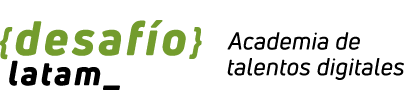



# <center><strong><font color="green">Distribución normal</font></strong></center>

## <strong><font color="green">Modelando con la distribución normal</font></strong>
Veremos como la distribución normal permite modelar algunos conjuntos de datos. Para ello necesitaremos importar algunas librerías y un conjunto de datos

In [112]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from scipy.stats import norm

dataset = pd.read_csv('height_weight.csv')

In [114]:
dataset.head(100)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
95,Male,65.117485,165.717112
96,Male,71.701234,193.094164
97,Male,66.832878,180.683887
98,Male,66.471275,172.773723


In [21]:
dataset.shape[1]

3

In [116]:
dataset.count()


Gender    10000
Height    10000
Weight    10000
dtype: int64

El dataset contiene los datos de genero, estatura (en pulgadas) y peso (en libras) de 10000 personas. Veremos algunos indicadores para la altura.

In [24]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [118]:
dataset['Height'].dropna().describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [26]:
dataset.describe(include="all")

,Gender,Height,Weight
count,10000,10000.000000,10000.000000
unique,2,NaN,NaN
top,Male,NaN,NaN
freq,5000,NaN,NaN
mean,NaN,66.367560,161.440357
std,NaN,3.847528,32.108439
min,NaN,54.263133,64.700127
25%,NaN,63.505620,135.818051
50%,NaN,66.318070,161.212928
75%,NaN,69.174262,187.169525


In [120]:
dataset.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


Si construimos un histograma de los datos de (Height = estatura) obtenemos lo siguiente:

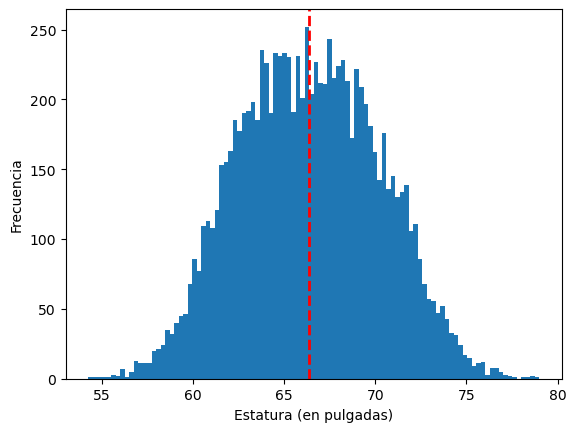

In [123]:
alturas = dataset['Height'].dropna() # asignamos la columna altura a la variable alturas
media = np.mean(alturas) # obtenemos el promedio de las alturas
plt.hist(alturas, bins=100) # llamamos a pyplot (su alias) seguido de hist, para generar un histograma, e indicamos que se divida el eje x en 100 intervalos

plt.axvline(x=media, color='red', linestyle='dashed', linewidth=2, label='Media') # insertamos la columna vertical (personalizada)


plt.xlabel('Estatura (en pulgadas)') # indicamos la etiqueta para el eje x

plt.ylabel('Frecuencia')# indicamos la etiqueta para el eje y

plt.show() # mostramos el grafico (en jupyter no es necesario indicarlo, pero siempre es mejor hacerlo)

Podemos observar que la distribución de los datos es bastante simétrica respecto de la media.




Veremos ahora como un modelo de distribucion normal puede ayudarnos a modelar esta situación.

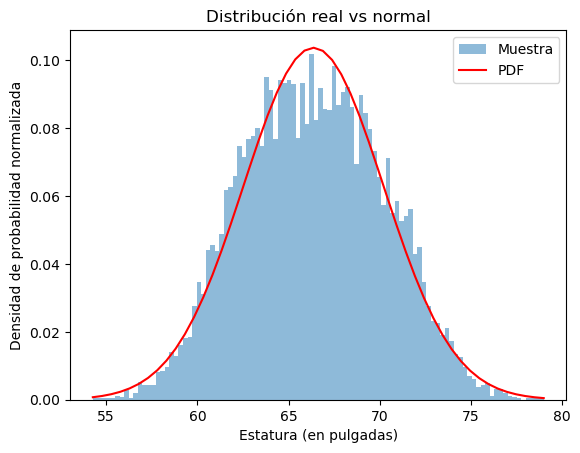

In [32]:
#Calculamos la media y la desviación estándar de los datos (estos son datos obtrenidos de la columna altura)
#además de los valores máximo y mínimo para graficar.

mu = alturas.mean()
sigma = alturas.std()
minimo= alturas.min()
maximo= alturas.max()

#Creamos un arreglo de valores equidistantes entre los valores mínimo y máximo, utilizando linspace
x = np.linspace(minimo, maximo)

#Creamos una función, llamada pdf, que calcula el valor de la función de distribución de probabilidad normal, con los parámetros dados
# Notemos que "sigma" funciona como "escala"
pdf = norm.pdf(x, loc=mu, scale=sigma)


# Histograma de los datos. El parámetro "density=True" va a construir el histograma haciendo que la suma de todas 
#las áreas de las barras sea igual a 1, para que podamos representar las probabilidades

plt.hist(alturas, bins=100, density=True, alpha=0.5, label='Muestra')#alpha=0.5 da un 50% de transparencia

plt.plot(x, pdf, color='red', label='PDF') #Graficamos la distribución normal

plt.xlabel('Estatura (en pulgadas)')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Distribución real vs normal')
plt.legend()
plt.show()


¿Y si comparamos ahora los pesos, para hombres y mujeres por separado? Vamos a extraer los datos

In [35]:
hombres = dataset[dataset['Gender']=='Male']['Weight']
mujeres = dataset[dataset['Gender']=='Female']['Weight']

Definiremos ahora una función que nos permita modelar un conjunto de datos con a distribución normal

In [47]:
def get_psd(x):
  mu=x.mean()
  sigma=x.std()
  minimo=x.min()
  maximo=x.max()
  x = np.linspace(minimo, maximo)
  pdf = norm.pdf(x, loc=mu, scale=sigma)
  return(x,pdf)



Con esto, ya podemos hacer nuestra comparación

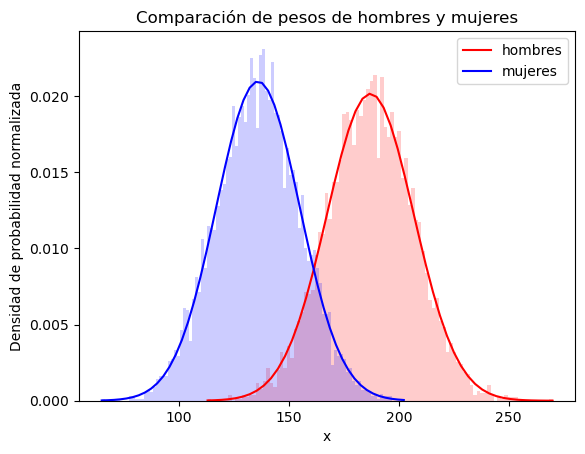

In [53]:
x1, pdf = get_psd(hombres)
plt.plot(x1 , pdf, color='red', label='hombres')

x2,pdf=get_psd(mujeres)
plt.plot(x2 , pdf, color='blue', label='mujeres')

plt.hist(hombres, bins=100, density=True, alpha=0.2, color='red')
plt.hist(mujeres, bins=100, density=True, alpha=0.2, color='blue')

plt.xlabel('x')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Comparación de pesos de hombres y mujeres')
plt.legend()
plt.show()

## <strong><font color="green">Parámetros la distribución normal</font></strong>

¿Cuál puede ser la importancia de los parámetros de una distribución normal? 


Como hemos mencionado, la media de los datos constituye un **eje de simetria** de la curva. Mientras mayor sea esta media, este eje estará más desplazado hacia la derecha. En el gráfico anterior puedes ver que el promedio para los hombres es mayor, lo que hace que el gráfico esté desplazado hacia la derecha en comparación al de las mujeres.

Para analizar el rol que cumple la desviación estándar, veremos algunos ejemplos de distribuciones normales con la misma media pero diferentes desviaciones.

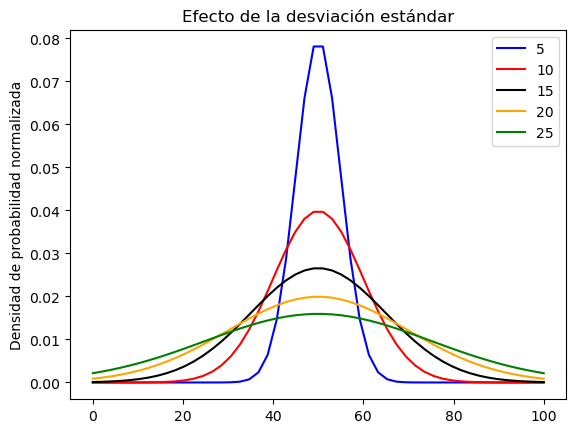

In [55]:
x = np.linspace(0, 100)# consideraremos un rango de valores entre 0 y 100

desv={5:'blue',10:'red',15:'black',20:'orange',25:'green'}

for clave,valor in desv.items():
  pdf = norm.pdf(x, loc=50, scale=clave)
  plt.plot(x, pdf, color=valor, label=clave)

plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Efecto de la desviación estándar')
plt.legend()
plt.show()

¿Qué ocurre cuando aumenta el valor de sigma?

## <strong><font color="green">Aplicación la distribución normal</font></strong>

Considerando el modelamiento anterior, vamos a comparar los resultados "reales" (es decir, considerando la lista de datos) con lo que predice un modelo basado en la distribución normal. Específicamente, nos preguntaremos ¿cuál es la probabilidad de que una persona al azar mida 72 pulgadas o menos?

Nuestra primera alternativa es determinar a qué percentil corresponde 72 en el conjunto de datos. Para esto necesitaremos cargar una librería.


## ¿Qué es norm.cdf y para qué sirve?
**norm.cdf** (Cumulative Distribution Function) es una función que se usa en estadística para calcular la probabilidad acumulada de una variable aleatoria que sigue una distribución normal. En términos sencillos, te dice qué porcentaje de los datos cae por debajo o en un cierto valor.

In [60]:
from scipy.stats import percentileofscore
alturas_prueba = [70,72,80,82,90,92]

for i in alturas_prueba:
  p_real=round(percentileofscore(alturas,i),2)

  p_modelo=round(100*norm.cdf(i, loc=mu, scale=sigma),2)

  print(f'El percentil real para {i} es {p_real}, y el teórico es {p_modelo}')

El percentil real para 70 es 81.22, y el teórico es 82.74
El percentil real para 72 es 92.71, y el teórico es 92.84
El percentil real para 80 es 100.0, y el teórico es 99.98
El percentil real para 82 es 100.0, y el teórico es 100.0
El percentil real para 90 es 100.0, y el teórico es 100.0
El percentil real para 92 es 100.0, y el teórico es 100.0


Esta comparación es muy útil porque nos permite evaluar qué tan bien se ajusta nuestro conjunto de datos alturas a una distribución normal teórica con una media "mu" y una desviación estándar "sigma" específicas.

In [63]:
# Si nos fijamos solo en la altura 72...

print(percentileofscore(alturas, 72))


92.71000000000001


Es decir, un 92,7% de las personas de la muestra mide 72 puldadas o menos. O, lo que es igual, la probabilidad de escoger a una persona al azar que mida 72 pulgadas o menos es 0,927, aproximadamente.

## ¿Qué ocurre si consideramos la función normal definida por el promedio y la desviación estándar de los datos?

In [66]:

mu = np.mean(alturas)
sigma = np.std(alturas)

# Valor específico para el cual queremos calcular la probabilidad
valor = 72

# Calcular la probabilidad acumulada
probabilidad = norm.cdf(valor, loc=mu, scale=sigma)

print("La probabilidad de obtener un valor menor o igual a", valor, "es:", probabilidad)


La probabilidad de obtener un valor menor o igual a 72 es: 0.9284009209133959


**mu** es el promedio (o media) de un conjunto de datos, en este caso las alturas. Esto representa el valor promedio de todas las alturas en el conjunto.

**sigma** es la desviación estándar, que mide cuánto se desvían los valores del conjunto respecto al promedio. Si la desviación estándar es baja, las alturas están más cercanas al promedio; si es alta, están más dispersas.

**norm.cdf** es una función que proviene de la distribución normal. Esta función nos da la probabilidad acumulada hasta un cierto punto, en este caso hasta el valor 72.

La función tiene tres parámetros:

* **valor** =  El valor específico (en este caso, 72).
* **loc** = mu: La media o promedio de los datos (el "centro" de la distribución).
* **scale** = sigma: La desviación estándar (qué tan dispersos están los datos).

La CDF nos da la probabilidad de que un valor aleatorio, proveniente de la distribución normal con media mu y desviación estándar sigma, sea menor o igual a 72.

Esto significa que hay un **92.84%** de probabilidad de que un valor, tomado aleatoriamente de esa distribución normal (es decir, alturas con un promedio y una desviación estándar determinados), sea menor o igual a 72.

**Ejemplo práctico:**

supongamos que las alturas siguen una distribución normal con media 68 pulgadas y una desviación estándar de 3 pulgadas. Cuando usamos norm.cdf(72, loc=68, scale=3), estamos preguntando: 
**"¿Cuál es la probabilidad de que una persona seleccionada al azar tenga una altura de 72 pulgadas o menos?"**

El resultado de **0.9087** nos dice que el **90.87%** de las personas están por debajo o en ese valor.

In [127]:
prob72 = norm.cdf(72, loc=68, scale=3)

print("La probabilidad de obtener un valor menor o igual a 72", "es:", prob72)

La probabilidad de obtener un valor menor o igual a 72 es: 0.9087887802741321


## Realizamos una modificación de la data

In [134]:
# Cargar el dataset
dataset = pd.read_csv('height_weight.csv')

# Definir el tamaño del dataset
total = len(dataset)

# Generar una nueva columna 'Smoker' con 61% fumadores (1) y 39% no fumadores (0)
dataset['Smoker'] = np.random.choice([True, False], size=total, p=[0.61, 0.39])

# Ver las primeras filas para verificar el resultado
dataset.head()

,Gender,Height,Weight,Smoker
0,Male,73.847017,241.893563,True
1,Male,68.781904,162.310473,True
2,Male,74.110105,212.740856,True
3,Male,71.730978,220.042470,False
4,Male,69.881796,206.349801,False


In [136]:
dataset.Smoker.value_counts()

Smoker
True     6056
False    3944
Name: count, dtype: int64

In [140]:
dataset['Smoker'].value_counts()

Smoker
True     6056
False    3944
Name: count, dtype: int64

### Paso 1: Definir la "Verdad" (Probabilidad $p$)

* Calculamos la probabilidad real de éxito en el dataset.
* Acción: Contamos cuántos fuman y dividimos por el total.
* Resultado: Obtenemos probabilidad de  $p $. Este es nuestro parámetro base.

In [86]:
#Seleccionamos los datos y cambiamos los True por 1 y False por cero. Con esto calculamos la probabilidad

datos = dataset['Smoker'].dropna()
fuma = np.where(datos, 1, 0)
p=sum(fuma)/len(fuma)


In [88]:
p

0.6132

In [144]:
#fuma 
# No fuma

array([0, 1, 1, ..., 0, 0, 1])

### Paso 2: El Modelo Teórico (Binomial)

* Simulamos el experimento usando una fórmula matemática perfecta.
* Acción: Usamos **np.random.binomial(n=5, p, size=8)**.
* Concepto: Python genera "datos ideales" basados en la probabilidad $p$. Repetimos esto 1,000 veces para obtener las medias.

* Resultado: Obtenemos una lista de 1,000 promedios que, por el TLC, deberían empezar a formar una campana.

### creamos muestrales binomiales 

In [92]:
medias_binom = []
for j in range(1000):
    medias_binom.append(np.mean(np.random.binomial( 5, p, size=8)))
    # n=5 (número de ensayos), p=p (probabilidad de éxito), size=8 (número de repeticiones del experimento binomial para esta muestra)


print(f"Media de las medias muestrales binomiales (simuladas): {np.mean(medias_binom):.4f}")
print(f"Desviación estándar de las medias muestrales binomiales (simuladas): {np.std(medias_binom):.4f}\n")

Media de las medias muestrales binomiales (simuladas): 3.0851
Desviación estándar de las medias muestrales binomiales (simuladas): 0.3819



### Paso 3: El Modelo Empírico (Datos Reales)

* Forzamos a los datos crudos a agruparse para ver cómo se comportan "en la calle".
* Acción: Sacamos al azar a 5 personas de la tabla original (choice) y sumamos cuántas fuman.
* Concepto: No usamos fórmulas, solo la frecuencia real de los datos. Creamos una "población" de 100,000 de estos experimentos y luego tomamos 1,000 medias.

In [95]:
# --- 3. Extracción de Muestras de Datos Reales y Cálculo de Medias Muestrales (con la población simulada) ---
# Primero, generamos una gran "población" de resultados del experimento binomial
# (número de fumadoras en 5 ) a partir de nuestros datos originales.

num_simulaciones_para_poblacion = 100000 # Un número grande
resultados_experimento_real = []
for _ in range(num_simulaciones_para_poblacion):
    muestra_5_madres = np.random.choice(fuma, size=5, replace=True) # Usar replace=True para independencia
    num_fumadoras_en_5 = sum(muestra_5_madres)
    resultados_experimento_real.append(num_fumadoras_en_5)

# Ahora, de esta "población" de resultados de nuestro experimento,
# extraemos 1000 muestras de tamaño 8 y calculamos sus medias.
medias_reales_simuladas = []
for k in range(1000):
    muestra_de_8_resultados = np.random.choice(resultados_experimento_real, size=8, replace=True)
    medias_reales_simuladas.append(np.mean(muestra_de_8_resultados))

print(f"Media de las medias muestrales reales (simuladas): {np.mean(medias_reales_simuladas):.4f}")
print(f"Desviación estándar de las medias muestrales reales (simuladas): {np.std(medias_reales_simuladas):.4f}\n")


Media de las medias muestrales reales (simuladas): 3.0577
Desviación estándar de las medias muestrales reales (simuladas): 0.3909



### Paso 4: Construcción del Modelo Normal Teórico (TLC)

Utilizamos el Teorema del Límite Central (TLC) para predecir matemáticamente cómo debería verse la distribución de nuestras medias muestrales.

In [96]:
# --- 4. Construir un modelo de distribución normal derivado del modelo binomial ---

# Parámetros de la distribución binomial para UNA observación (n=5, p=p)
n_binomial = 5
p_binomial = p

# La media de una distribución binomial es n*p
media_poblacion_binomial = n_binomial * p_binomial

# La varianza de una distribución binomial es n*p*(1-p)
varianza_poblacion_binomial = n_binomial * p_binomial * (1 - p_binomial)

# Según el Teorema del Límite Central, la distribución de las medias muestrales
# de muestras de tamaño 'm' (en nuestro caso m=8) se aproxima a una Normal con:
# Media (mu) = media de la población = media_poblacion_binomial
# Desviación estándar (sigma) = sqrt(varianza de la población / m)
# En este caso, 'm' es el tamaño de la muestra para las medias (8)

mu_normal = media_poblacion_binomial
sigma_normal = np.sqrt(varianza_poblacion_binomial / 8) # Dividido por el tamaño de la muestra (8)

print(f"Parámetros de la distribución Normal derivada:")
print(f"  Media (mu): {mu_normal:.4f}")
print(f"  Desviación Estándar (sigma): {sigma_normal:.4f}\n")

# Crear puntos para graficar la curva de la distribución normal
x = np.linspace(min(min(medias_binom), min(medias_reales_simuladas)) - 0.5,
                max(max(medias_binom), max(medias_reales_simuladas)) + 0.5, 500)
pdf_normal = norm.pdf(x, loc=mu_normal, scale=sigma_normal)

Parámetros de la distribución Normal derivada:
  Media (mu): 3.0660
  Desviación Estándar (sigma): 0.3850



* La **Media (3.0650)** nos dice dónde **'debe'** estar el pico de la montaña, y la **Desviación (0.3851)** nos dice qué tan **'gorda'** debe ser. Es nuestra regla para medir qué tan bien funcionan los datos reales".

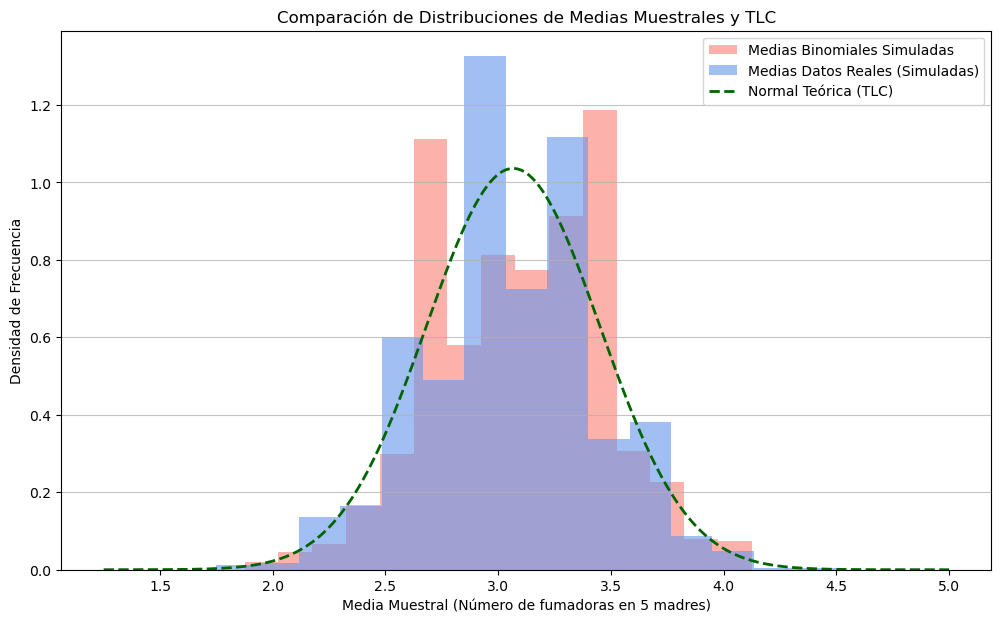

In [98]:
# --- 5. Graficar y Comparar ---
plt.figure(figsize=(12, 7))

# Histograma de las medias binomiales simuladas
plt.hist(medias_binom, bins=15, density=True, alpha=0.6, color='salmon', label='Medias Binomiales Simuladas')

# Histograma de las medias de datos reales simulados
plt.hist(medias_reales_simuladas, bins=15, density=True, alpha=0.6, color='cornflowerblue', label='Medias Datos Reales (Simuladas)')

# Curva de la distribución normal teórica
plt.plot(x, pdf_normal, color='darkgreen', linestyle='--', linewidth=2, label='Normal Teórica (TLC)')

plt.xlabel('Media Muestral (Número de fumadoras en 5 madres)')
plt.ylabel('Densidad de Frecuencia')
plt.title('Comparación de Distribuciones de Medias Muestrales y TLC')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()



In [147]:
# --- 6. Conclusión ---
print("\n--- Conclusión ---")
print("El gráfico muestra tres distribuciones:")
print("1. El histograma rojo/salmón representa la distribución de las medias muestrales obtenidas al simular el experimento binomial (5, p) 1000 veces, tomando la media de 8 de estos resultados.")
print("2. El histograma azul/cornflowerblue representa la distribución de las medias muestrales obtenidas al simular la extracción de grupos de 5 madres de los datos reales para crear una 'población' de resultados, y luego tomar la media de 8 de estos resultados simulados 1000 veces.")
print("3. La línea verde punteada es la Función de Densidad de Probabilidad (PDF) de una distribución Normal teórica, cuyos parámetros (media y desviación estándar) se derivan directamente del modelo binomial y el tamaño de la muestra (8), según el Teorema del Límite Central.")
print("\nVerificación del Teorema del Límite Central (TLC):")
print(f"Observamos que las medias de las muestras simuladas (binomial y reales) son muy cercanas a la media teórica de la Normal ({mu_normal:.4f}).")
print(f"De manera similar, las desviaciones estándar de las muestras simuladas ({np.std(medias_binom):.4f} y {np.std(medias_reales_simuladas):.4f}) son muy cercanas a la desviación estándar teórica de la Normal ({sigma_normal:.4f}).")
print("Visualmente, los histogramas de las medias muestrales (tanto las simuladas con el modelo binomial como las derivadas de los datos reales) se **aproximan estrechamente a la forma de campana de la distribución Normal teórica**.")
print("Esto proporciona una clara **verificación del Teorema del Límite Central**: la distribución de las medias muestrales tiende a ser Normal, independientemente de la distribución original de la población (que en este caso es binomial), siempre que el tamaño de la muestra sea suficientemente grande (aquí, n=8).")
print("\nLas pequeñas diferencias entre los histogramas y la curva Normal se deben a la naturaleza de la simulación y al tamaño de muestra finito (tanto de las muestras como de las simulaciones Monte Carlo). Aumentar el número de simulaciones (1000) y el tamaño de las muestras (8) haría que la aproximación fuera aún más precisa.")


--- Conclusión ---
El gráfico muestra tres distribuciones:
1. El histograma rojo/salmón representa la distribución de las medias muestrales obtenidas al simular el experimento binomial (5, p) 1000 veces, tomando la media de 8 de estos resultados.
2. El histograma azul/cornflowerblue representa la distribución de las medias muestrales obtenidas al simular la extracción de grupos de 5 madres de los datos reales para crear una 'población' de resultados, y luego tomar la media de 8 de estos resultados simulados 1000 veces.
3. La línea verde punteada es la Función de Densidad de Probabilidad (PDF) de una distribución Normal teórica, cuyos parámetros (media y desviación estándar) se derivan directamente del modelo binomial y el tamaño de la muestra (8), según el Teorema del Límite Central.

Verificación del Teorema del Límite Central (TLC):
Observamos que las medias de las muestras simuladas (binomial y reales) son muy cercanas a la media teórica de la Normal (3.0660).
De manera similar, la

El objetivo general es muy bueno: comparar una distribución teórica (binomial) con la distribución empírica de las medias muestrales obtenidas directamente de los datos. Esto es fundamental para entender cómo se comportan las muestras y cómo se relaciona la teoría con la práctica.

Estamos generando 1000 muestras teóricas a partir de un modelo binomial. El objetivo es simular cómo se comporta el experimento de seleccionar 5 registros al azar repetido 8 veces en cada muestra. Se Está usando la función **np.random.binomial** para generar resultados binomiales, y luego calculamos la media muestral de cada muestra. Esto lo haces 1000 veces.

en lugar de usar el modelo teórico binomial, tomamos 1000 muestras de los datos reales. En cada muestra, seleccionas 5 registros  de forma aleatoria sin reemplazo (con np.random.choice). Luego, para cada muestra calculamos la media de cuántos de esos 5 registros fuman. Esto nos da 1000 medias muestrales basadas en datos reales.

Finalmente, graficamos ambas distribuciones:

* La distribución de las medias muestrales teóricas (simuladas usando el modelo binomial) en rojo.
* La distribución de las medias muestrales reales (obtenidas a partir de tus datos) en azul.
  

## Verificación del Teorema del Límite Central (TLC)

El Teorema del Límite Central establece que, a medida que tomamos más muestras de una población (sin importar la distribución original), la distribución de las medias muestrales tenderá a aproximarse a una distribución normal.


Qué estamos haciendo en este ejercicio:

Estamos generando medias muestrales tanto a partir del modelo teórico (binomial) como de los datos reales.
Al graficar los histogramas, esperamos ver que las medias de las muestras sigan una forma que se aproxime a la distribución normal. En este caso, ambas distribuciones (real y binomial) deberían empezar a parecerse a una campana simétrica.


## ¿Para qué sirve este ejercicio?

* **Simulación de modelos teóricos:** nos permite comparar si el modelo binomial teórico es una buena aproximación de la realidad.


* **Validación del Teorema del Límite Central:** Nos muestra que, aunque los datos individuales pueden no seguir una distribución normal, las medias muestrales tenderán a aproximarse a una normalidad, lo que es uno de los resultados más importantes en estadística.


* **Comparación gráfica:** Nos ayuda a visualizar si la distribución de medias teóricas (modelo binomial) es similar a las medias obtenidas de los datos reales. Si los histogramas son similares, significa que nuestro modelo binomial representa bien el comportamiento real.